### Importing Important Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Loading and Merging the data

In [50]:
transaction = pd.read_csv("../data/train_transaction.csv")
identity = pd.read_csv("../data/train_identity.csv")

data = transaction.merge(identity, on="TransactionID", how="left")
print(data.shape)

(590540, 434)


### Seperating target Variable

In [51]:
X = data.drop("isFraud", axis=1)
y = data["isFraud"]

### Handling Missing Values

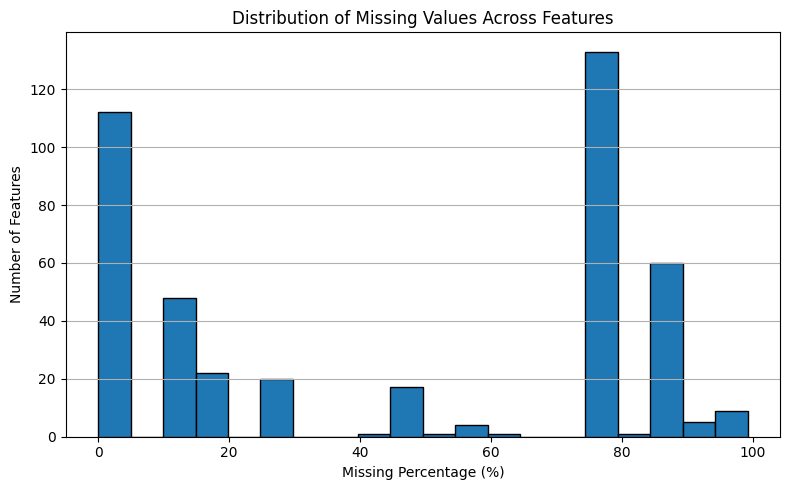

In [52]:
import matplotlib.pyplot as plt

missing_percent = data.isnull().mean() * 100

plt.figure(figsize=(8,5))
plt.hist(missing_percent, bins=20, edgecolor="black")
plt.title("Distribution of Missing Values Across Features")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Features")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

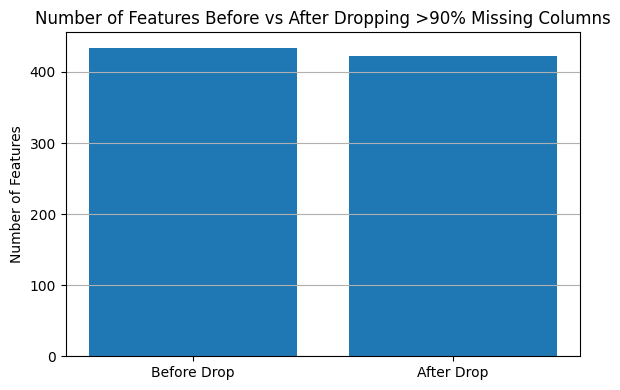

Columns before: 434
Columns dropped: 12
Columns after: 422


In [53]:
# Dropping columns with extreme missing values(threshold >90%)
drop_cols = missing_percent[missing_percent > 90].index

threshold = 90

before_cols = data.shape[1]
drop_cols = missing_percent[missing_percent > threshold].index
X = X.drop(columns=drop_cols)
after_cols = before_cols - len(drop_cols)

plt.figure(figsize=(6,4))
plt.bar(["Before Drop", "After Drop"], [before_cols, after_cols])
plt.title("Number of Features Before vs After Dropping >90% Missing Columns")
plt.ylabel("Number of Features")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("Columns before:", before_cols)
print("Columns dropped:", len(drop_cols))
print("Columns after:", after_cols)

Now, lets fill missing values with the median for the numerical clomuns. And for the categorical ones, lets just categorize this as "Missing"

In [54]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Missing")

### Encoding Categorical Variables

In [55]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape after encoding:", X.shape)

Shape after encoding: (590540, 2818)


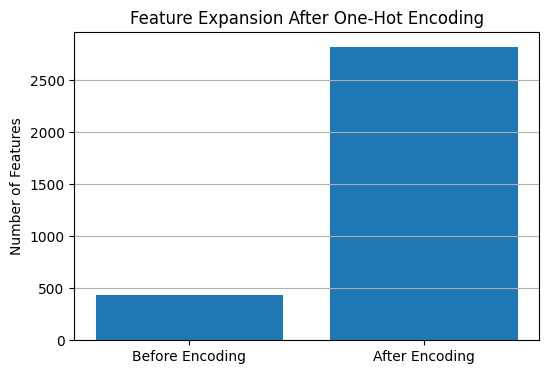

In [56]:
import matplotlib.pyplot as plt

before = transaction.shape[1] + identity.shape[1]
after = X.shape[1]

plt.figure(figsize=(6,4))
plt.bar(["Before Encoding", "After Encoding"], [before, after])
plt.title("Feature Expansion After One-Hot Encoding")
plt.ylabel("Number of Features")
plt.grid(axis="y")
plt.show()

### Feature Engineering

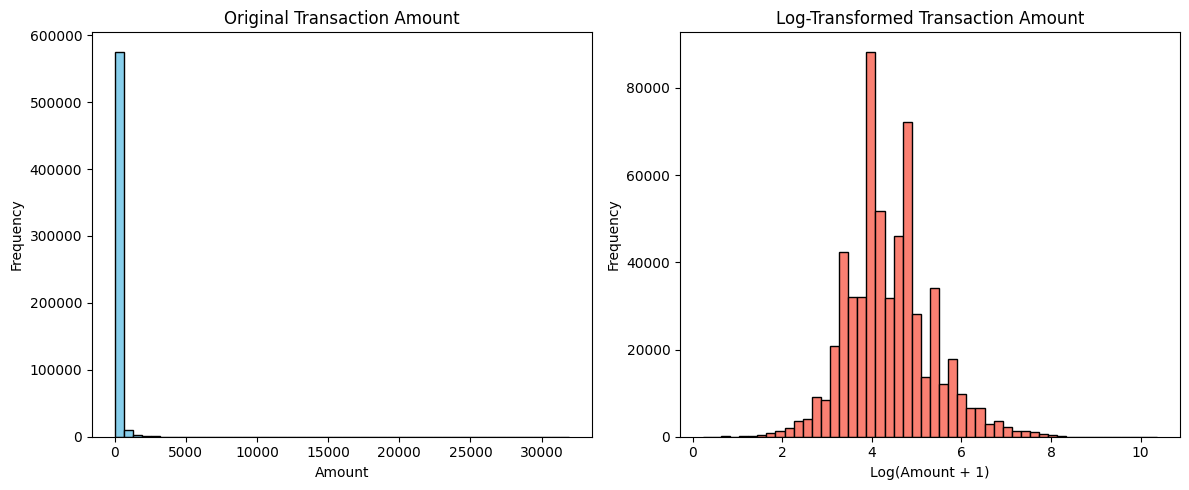

In [57]:
X["TransactionAmt_log"] = np.log1p(X["TransactionAmt"])

plt.figure(figsize=(12,5))

# Original Transaction Amount
plt.subplot(1,2,1)
plt.hist(X["TransactionAmt"], bins=50, color="skyblue", edgecolor="black")
plt.title("Original Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# Log-transformed Transaction Amount
plt.subplot(1,2,2)
plt.hist(np.log1p(X["TransactionAmt"]), bins=50, color="salmon", edgecolor="black")
plt.title("Log-Transformed Transaction Amount")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [58]:
X["TransactionDT_hours"] = X["TransactionDT"] / 3600
X["TransactionDT_days"] = X["TransactionDT"] / (3600 * 24)

Train/Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.03498916246147594
Test fraud rate: 0.0349933958749619


Save Processed Data

In [60]:
import os

os.makedirs("../outputs", exist_ok=True)

X_train.to_csv("../outputs/X_train_processed.csv", index=False)
X_test.to_csv("../outputs/X_test_processed.csv", index=False)

pd.Series(y_train).to_csv("../outputs/y_train.csv", index=False)
pd.Series(y_test).to_csv("../outputs/y_test.csv", index=False)